# model training MLP vs GCN vs GAT (5-fold cross-validation)

In [1]:
%pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from dataset.dataset_util import load_esol, split_dataset, kfold_indices, make_loaders, get_fingerprints, rmse, mae, r_squared
from gnns.gnn_util import GCNModel, GATModel, run_training, get_predictions
from nn.nn_util import MLPModel, run_training_mlp, get_predictions_mlp

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## data

In [10]:
dataset = load_esol(root='data/')
train_set, test_set = split_dataset(dataset, test_ratio=0.2, seed=42)

# graph loaders for GCN/GAT (full training set → final model; test for evaluation)
train_loader, test_loader = make_loaders(train_set, test_set, batch_size=64)

# fingerprints for MLP
X_train, y_train = get_fingerprints(train_set)
X_test, y_test = get_fingerprints(test_set)

# k-fold indices for cross-validation
K = 5
folds = kfold_indices(len(train_set), k=K, seed=42)

print(f'train: {len(train_set)}  test: {len(test_set)}  ({K}-fold CV on train set)')

train: 902  val: 112  test: 114


## optional: load saved models

Set `LOAD_SAVED_WEIGHTS` to `True` in the next cell, run it right after the data cell, then **skip** the three training sections (MLP, GCN, GAT). You need the model files under `models/` (`.pt` weights plus `cv_results.json`). CV metrics are restored so comparison plots still work.

In [11]:
LOAD_SAVED_WEIGHTS = True

if LOAD_SAVED_WEIGHTS:
    import json
    from pathlib import Path

    MODEL_DIR = Path('models')
    required = [MODEL_DIR / 'mlp.pt', MODEL_DIR / 'gcn.pt', MODEL_DIR / 'gat.pt', MODEL_DIR / 'cv_results.json']
    missing = [p for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError('missing ' + ', '.join(str(p) for p in missing) + ' — train and run the save cell first.')

    mlp = MLPModel(in_features=1024, hidden=128)
    mlp.load_state_dict(torch.load(MODEL_DIR / 'mlp.pt', map_location='cpu'))

    gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
    gcn.load_state_dict(torch.load(MODEL_DIR / 'gcn.pt', map_location='cpu'))

    gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
    gat.load_state_dict(torch.load(MODEL_DIR / 'gat.pt', map_location='cpu'))

    with open(MODEL_DIR / 'cv_results.json') as f:
        cv_results = json.load(f)
    mlp_cv = cv_results['mlp']
    gcn_cv = cv_results['gcn']
    gat_cv = cv_results['gat']
    mlp_fold_histories = cv_results.get('mlp_fold_histories', [])
    gcn_fold_histories = cv_results.get('gcn_fold_histories', [])
    gat_fold_histories = cv_results.get('gat_fold_histories', [])


## train MLP (5-fold CV + final model)

In [5]:
mlp_cv = {'rmse': [], 'mae': [], 'r2': []}
mlp_fold_histories = []

print('MLP 5-fold cross-validation')
for fold_i, (tr_idx, vl_idx) in enumerate(folds):
    print(f'--- fold {fold_i+1}/{K} ---')
    fold_train, fold_val = train_set[tr_idx], train_set[vl_idx]
    X_tr, y_tr = get_fingerprints(fold_train)
    X_vl, y_vl = get_fingerprints(fold_val)

    model_f = MLPModel(in_features=1024, hidden=128)
    hist = run_training_mlp(model_f, X_tr, y_tr, X_vl, y_vl, epochs=10000, lr=0.001, verbose=False)
    mlp_fold_histories.append(hist)

    preds = get_predictions_mlp(model_f, X_vl)
    fold_rmse = rmse(preds.squeeze(), y_vl.squeeze())
    fold_mae = mae(preds.squeeze(), y_vl.squeeze())
    fold_r2 = r_squared(preds.squeeze(), y_vl.squeeze())
    mlp_cv['rmse'].append(fold_rmse)
    mlp_cv['mae'].append(fold_mae)
    mlp_cv['r2'].append(fold_r2)
    print(f'  RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R\u00b2: {fold_r2:.4f}')

print(f'\nMLP CV average \u2014 RMSE: {np.mean(mlp_cv["rmse"]):.4f}  MAE: {np.mean(mlp_cv["mae"]):.4f}  R\u00b2: {np.mean(mlp_cv["r2"]):.4f}')

# final model on full training set
mlp = MLPModel(in_features=1024, hidden=128)
run_training_mlp(mlp, X_train, y_train, epochs=10000, lr=0.001, verbose=False)
print('final MLP trained on full training set')

training MLP...
  epoch   1  train 8.6831  val 11.1254
  epoch  20  train 0.2726  val 1.4184
  epoch  40  train 0.1964  val 1.2678
  epoch  60  train 0.1839  val 1.2109
  epoch  80  train 0.1874  val 1.1517
  epoch 100  train 0.1958  val 1.2689
  epoch 120  train 0.1652  val 1.3263
  epoch 140  train 0.2009  val 1.2139
  epoch 160  train 0.1892  val 1.2247
  epoch 180  train 0.2322  val 1.3342
  epoch 200  train 0.1965  val 1.2531
  epoch 220  train 0.2183  val 1.3646
  epoch 240  train 0.2105  val 1.2894
  epoch 260  train 0.1506  val 1.2947
  epoch 280  train 0.1737  val 1.3231
  epoch 300  train 0.1915  val 1.3150
  epoch 320  train 0.1792  val 1.2664


KeyboardInterrupt: 

## train GCN (5-fold CV + final model)

In [ ]:
from torch_geometric.loader import DataLoader

gcn_cv = {'rmse': [], 'mae': [], 'r2': []}
gcn_fold_histories = []

print('GCN 5-fold cross-validation')
for fold_i, (tr_idx, vl_idx) in enumerate(folds):
    print(f'--- fold {fold_i+1}/{K} ---')
    fold_train, fold_val = train_set[tr_idx], train_set[vl_idx]
    fold_tr_loader = DataLoader(fold_train, batch_size=64, shuffle=True)
    fold_vl_loader = DataLoader(fold_val, batch_size=64)

    model_f = GCNModel(in_channels=dataset.num_node_features, hidden=128)
    hist = run_training(model_f, fold_tr_loader, fold_vl_loader, epochs=10000, lr=0.001, verbose=False)
    gcn_fold_histories.append(hist)

    preds, targets = get_predictions(model_f, fold_vl_loader)
    fold_rmse = rmse(preds, targets)
    fold_mae = mae(preds, targets)
    fold_r2 = r_squared(preds, targets)
    gcn_cv['rmse'].append(fold_rmse)
    gcn_cv['mae'].append(fold_mae)
    gcn_cv['r2'].append(fold_r2)
    print(f'  RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R\u00b2: {fold_r2:.4f}')

print(f'\nGCN CV average \u2014 RMSE: {np.mean(gcn_cv["rmse"]):.4f}  MAE: {np.mean(gcn_cv["mae"]):.4f}  R\u00b2: {np.mean(gcn_cv["r2"]):.4f}')

# final model on full training set
gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
run_training(gcn, train_loader, epochs=10000, lr=0.001, verbose=False)
print('final GCN trained on full training set')

training GCN...
  epoch   1  train 12.9258  val 12.0495
  epoch  20  train 1.1379  val 1.1524
  epoch  40  train 0.8946  val 1.1686
  epoch  60  train 0.8772  val 1.4314
  epoch  80  train 0.7479  val 0.9641
  epoch 100  train 0.8901  val 1.5274
  epoch 120  train 0.6402  val 0.9365
  epoch 140  train 0.6919  val 1.7362
  epoch 160  train 0.6954  val 1.3103
  epoch 180  train 0.8941  val 1.1227
  epoch 200  train 0.6158  val 0.8680
  epoch 220  train 0.6578  val 0.9229
  epoch 240  train 0.6017  val 1.1831
  epoch 260  train 0.5963  val 0.8491
  epoch 280  train 0.5266  val 1.0965
  epoch 300  train 0.4994  val 1.0739
  epoch 320  train 0.5517  val 1.1963
  epoch 340  train 0.4974  val 0.8110
  epoch 360  train 0.5500  val 0.9078
  epoch 380  train 0.5234  val 0.9131
  epoch 400  train 0.5795  val 1.0817
  epoch 420  train 0.5249  val 0.9046
  epoch 440  train 0.4514  val 0.7934
  epoch 460  train 0.5189  val 0.8990
  epoch 480  train 0.4821  val 0.7993
  epoch 500  train 0.4654  val 0

## train GAT (5-fold CV + final model)

In [ ]:
gat_cv = {'rmse': [], 'mae': [], 'r2': []}
gat_fold_histories = []

print('GAT 5-fold cross-validation')
for fold_i, (tr_idx, vl_idx) in enumerate(folds):
    print(f'--- fold {fold_i+1}/{K} ---')
    fold_train, fold_val = train_set[tr_idx], train_set[vl_idx]
    fold_tr_loader = DataLoader(fold_train, batch_size=64, shuffle=True)
    fold_vl_loader = DataLoader(fold_val, batch_size=64)

    model_f = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
    hist = run_training(model_f, fold_tr_loader, fold_vl_loader, epochs=10000, lr=0.001, verbose=False)
    gat_fold_histories.append(hist)

    preds, targets = get_predictions(model_f, fold_vl_loader)
    fold_rmse = rmse(preds, targets)
    fold_mae = mae(preds, targets)
    fold_r2 = r_squared(preds, targets)
    gat_cv['rmse'].append(fold_rmse)
    gat_cv['mae'].append(fold_mae)
    gat_cv['r2'].append(fold_r2)
    print(f'  RMSE: {fold_rmse:.4f}  MAE: {fold_mae:.4f}  R\u00b2: {fold_r2:.4f}')

print(f'\nGAT CV average \u2014 RMSE: {np.mean(gat_cv["rmse"]):.4f}  MAE: {np.mean(gat_cv["mae"]):.4f}  R\u00b2: {np.mean(gat_cv["r2"]):.4f}')

# final model on full training set
gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
run_training(gat, train_loader, epochs=10000, lr=0.001, verbose=False)
print('final GAT trained on full training set')

training GAT...
  epoch   1  train 9.2897  val 9.1831
  epoch  20  train 0.8840  val 1.4004
  epoch  40  train 0.6568  val 0.8992
  epoch  60  train 0.6210  val 1.9369
  epoch  80  train 0.4971  val 0.7052
  epoch 100  train 0.5128  val 0.7157
  epoch 120  train 0.4834  val 0.7160
  epoch 140  train 0.4852  val 0.6991
  epoch 160  train 0.4243  val 0.6589
  epoch 180  train 0.4431  val 0.6044
  epoch 200  train 0.4026  val 0.8061
  epoch 220  train 0.3904  val 0.6698
  epoch 240  train 0.3938  val 1.3721
  epoch 260  train 0.3230  val 0.8775
  epoch 280  train 0.3169  val 0.7096
  epoch 300  train 0.3566  val 0.6101
  epoch 320  train 0.3553  val 0.6760
  epoch 340  train 0.3143  val 0.5966
  epoch 360  train 0.3272  val 0.5812
  epoch 380  train 0.3362  val 0.7025
  epoch 400  train 0.2935  val 0.5560
  epoch 420  train 0.3428  val 0.6307
  epoch 440  train 0.3315  val 0.6936
  epoch 460  train 0.3238  val 1.2273
  epoch 480  train 0.2892  val 0.6312
  epoch 500  train 0.3160  val 0.6

## save trained models

Writes final model weights and CV results under `models/` so you can reload later (see optional load section above) without retraining.

In [12]:
import json
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

torch.save(mlp.state_dict(), MODEL_DIR / 'mlp.pt')
torch.save(gcn.state_dict(), MODEL_DIR / 'gcn.pt')
torch.save(gat.state_dict(), MODEL_DIR / 'gat.pt')
with open(MODEL_DIR / 'cv_results.json', 'w') as f:
    json.dump({
        'mlp': mlp_cv, 'gcn': gcn_cv, 'gat': gat_cv,
        'mlp_fold_histories': mlp_fold_histories,
        'gcn_fold_histories': gcn_fold_histories,
        'gat_fold_histories': gat_fold_histories,
    }, f)
print('saved to', MODEL_DIR.resolve())

saved to C:\Users\Bill\Github\molecular-solubility\models


## test evaluation

In [13]:
mlp_cv_rmse, mlp_cv_mae, mlp_cv_r2 = np.mean(mlp_cv['rmse']), np.mean(mlp_cv['mae']), np.mean(mlp_cv['r2'])
gcn_cv_rmse, gcn_cv_mae, gcn_cv_r2 = np.mean(gcn_cv['rmse']), np.mean(gcn_cv['mae']), np.mean(gcn_cv['r2'])
gat_cv_rmse, gat_cv_mae, gat_cv_r2 = np.mean(gat_cv['rmse']), np.mean(gat_cv['mae']), np.mean(gat_cv['r2'])

print('5-fold CV averages')
print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"R\u00b2":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_cv_rmse:8.4f}  {mlp_cv_mae:8.4f}  {mlp_cv_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_cv_rmse:8.4f}  {gcn_cv_mae:8.4f}  {gcn_cv_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_cv_rmse:8.4f}  {gat_cv_mae:8.4f}  {gat_cv_r2:8.4f}')

# test set predictions (final models)
mlp_preds = get_predictions_mlp(mlp, X_test)
mlp_test_rmse = rmse(mlp_preds.squeeze(), y_test.squeeze())
mlp_test_mae = mae(mlp_preds.squeeze(), y_test.squeeze())
mlp_test_r2 = r_squared(mlp_preds.squeeze(), y_test.squeeze())

gcn_preds, gcn_targets = get_predictions(gcn, test_loader)
gcn_test_rmse = rmse(gcn_preds, gcn_targets)
gcn_test_mae = mae(gcn_preds, gcn_targets)
gcn_test_r2 = r_squared(gcn_preds, gcn_targets)

gat_preds, gat_targets = get_predictions(gat, test_loader)
gat_test_rmse = rmse(gat_preds, gat_targets)
gat_test_mae = mae(gat_preds, gat_targets)
gat_test_r2 = r_squared(gat_preds, gat_targets)

print(f'\ntest set evaluation (final models)')
print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"R\u00b2":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_test_rmse:8.4f}  {mlp_test_mae:8.4f}  {mlp_test_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_test_rmse:8.4f}  {gcn_test_mae:8.4f}  {gcn_test_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_test_rmse:8.4f}  {gat_test_mae:8.4f}  {gat_test_r2:8.4f}')

print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}  {"RÂ²":>8s}')
print(f'{"-"*38}')
print(f'{"MLP":<8s}  {mlp_rmse:8.4f}  {mlp_mae:8.4f}  {mlp_r2:8.4f}')
print(f'{"GCN":<8s}  {gcn_rmse:8.4f}  {gcn_mae:8.4f}  {gcn_r2:8.4f}')
print(f'{"GAT":<8s}  {gat_rmse:8.4f}  {gat_mae:8.4f}  {gat_r2:8.4f}')

model         RMSE       MAE       RÂ²
--------------------------------------
MLP         1.1294    0.8545    0.6961
GCN         0.8766    0.6948    0.8169
GAT         0.7398    0.5491    0.8696


## loss curves (averaged across folds)

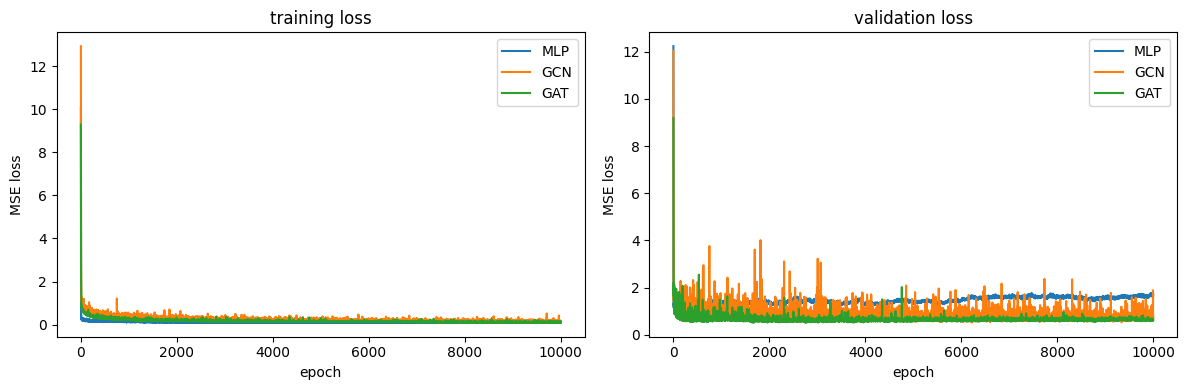

In [14]:
def avg_curve(fold_histories, key):
    arrays = [np.array(h[key]) for h in fold_histories if key in h]
    min_len = min(len(a) for a in arrays)
    return np.mean([a[:min_len] for a in arrays], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(avg_curve(mlp_fold_histories, 'train_loss'), label='MLP')
ax1.plot(avg_curve(gcn_fold_histories, 'train_loss'), label='GCN')
ax1.plot(avg_curve(gat_fold_histories, 'train_loss'), label='GAT')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE loss')
ax1.set_title('training loss (avg across folds)')
ax1.legend()

ax2.plot(avg_curve(mlp_fold_histories, 'val_loss'), label='MLP')
ax2.plot(avg_curve(gcn_fold_histories, 'val_loss'), label='GCN')
ax2.plot(avg_curve(gat_fold_histories, 'val_loss'), label='GAT')
ax2.set_xlabel('epoch')
ax2.set_ylabel('MSE loss')
ax2.set_title('validation loss (avg across folds)')
ax2.legend()

plt.tight_layout()
plt.show()

## predicted vs actual

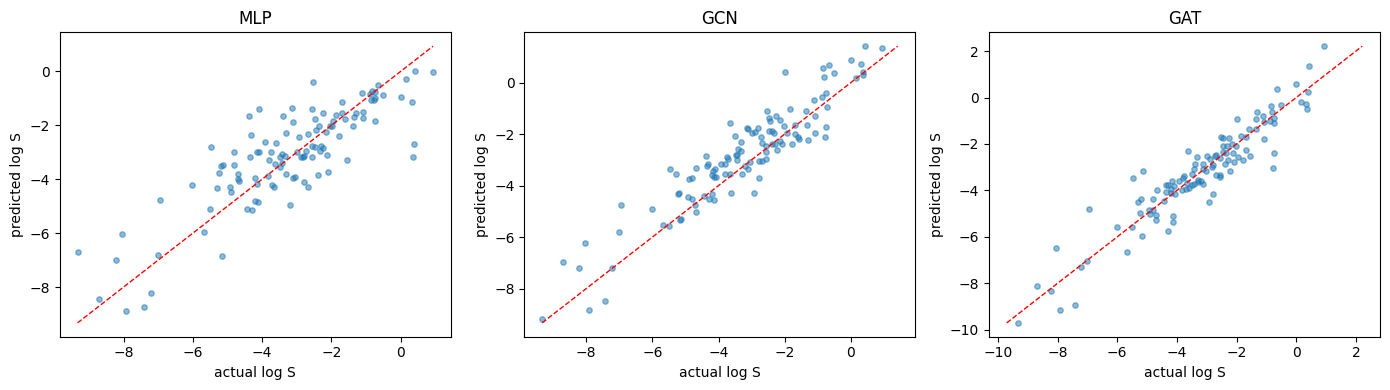

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_preds = [
    (mlp_preds.squeeze().detach().numpy(), y_test.squeeze().numpy(), 'MLP'),
    (gcn_preds.detach().numpy(), gcn_targets.detach().numpy(), 'GCN'),
    (gat_preds.detach().numpy(), gat_targets.detach().numpy(), 'GAT'),
]

for ax, (p, t, name) in zip(axes, all_preds):
    ax.scatter(t, p, alpha=0.5, s=15)
    lo = min(t.min(), p.min())
    hi = max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('actual log S')
    ax.set_ylabel('predicted log S')
    ax.set_title(f'{name} (test set)')

plt.tight_layout()
plt.show()

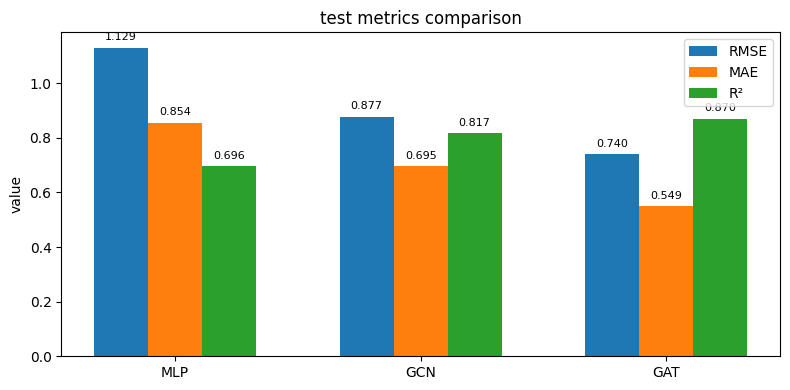

percentage improvement over MLP baseline
metric           GCN         GAT
--------------------------------
RMSE           22.4%       34.5%
MAE            18.7%       35.7%
R²             39.8%       57.1%


In [16]:
model_names = ['MLP', 'GCN', 'GAT']
rmse_vals = [mlp_cv_rmse, gcn_cv_rmse, gat_cv_rmse]
mae_vals = [mlp_cv_mae, gcn_cv_mae, gat_cv_mae]
r2_vals = [mlp_cv_r2, gcn_cv_r2, gat_cv_r2]

x = np.arange(3)
width = 0.22

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, rmse_vals, width, label='RMSE')
ax.bar(x,         mae_vals,  width, label='MAE')
ax.bar(x + width, r2_vals,   width, label='R\u00b2')

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('value')
ax.set_title('5-fold CV metrics comparison')
ax.legend()

for i, (r, m, r2) in enumerate(zip(rmse_vals, mae_vals, r2_vals)):
    ax.text(i - width, r + 0.02, f'{r:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i,         m + 0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width, r2 + 0.02, f'{r2:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

rmse_improv_gcn = (mlp_cv_rmse - gcn_cv_rmse) / mlp_cv_rmse * 100
rmse_improv_gat = (mlp_cv_rmse - gat_cv_rmse) / mlp_cv_rmse * 100
mae_improv_gcn = (mlp_cv_mae - gcn_cv_mae) / mlp_cv_mae * 100
mae_improv_gat = (mlp_cv_mae - gat_cv_mae) / mlp_cv_mae * 100
r2_improv_gcn = (gcn_cv_r2 - mlp_cv_r2) / (1 - mlp_cv_r2) * 100
r2_improv_gat = (gat_cv_r2 - mlp_cv_r2) / (1 - mlp_cv_r2) * 100

print('percentage improvement over MLP baseline (CV averages)')
print(f'{"metric":<8s}  {"GCN":>10s}  {"GAT":>10s}')
print(f'{"-"*32}')
print(f'{"RMSE":<8s}  {rmse_improv_gcn:>9.1f}%  {rmse_improv_gat:>9.1f}%')
print(f'{"MAE":<8s}  {mae_improv_gcn:>9.1f}%  {mae_improv_gat:>9.1f}%')
print(f'{"R\u00b2":<8s}  {r2_improv_gcn:>9.1f}%  {r2_improv_gat:>9.1f}%')

## error distribution

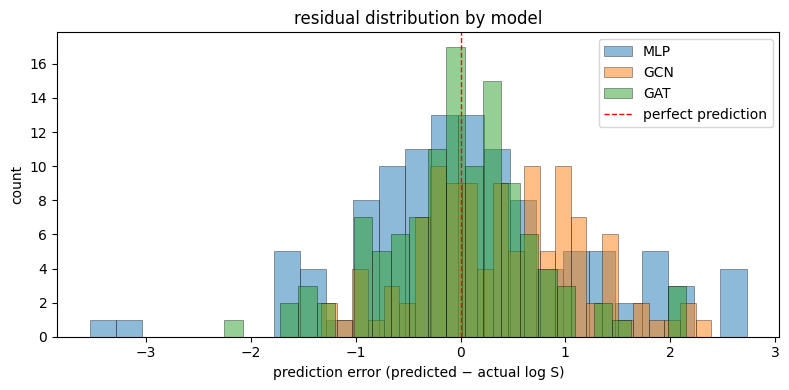

In [17]:
mlp_residuals = (mlp_preds.squeeze() - y_test.squeeze()).detach().numpy()
gcn_residuals = (gcn_preds - gcn_targets).detach().numpy()
gat_residuals = (gat_preds - gat_targets).detach().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mlp_residuals, bins=25, alpha=0.5, label='MLP', edgecolor='black', linewidth=0.5)
ax.hist(gcn_residuals, bins=25, alpha=0.5, label='GCN', edgecolor='black', linewidth=0.5)
ax.hist(gat_residuals, bins=25, alpha=0.5, label='GAT', edgecolor='black', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='perfect prediction')
ax.set_xlabel('prediction error (predicted \u2212 actual log S)')
ax.set_ylabel('count')
ax.set_title('residual distribution by model')
ax.legend()
plt.tight_layout()
plt.show()

## best and worst predictions (GAT)

In [18]:
import pandas as pd

smiles_list = [data.smiles for data in test_set]
gat_errors = (gat_preds - gat_targets).abs()

sorted_idx = gat_errors.argsort()
best_idx = sorted_idx[:5].tolist()
worst_idx = sorted_idx[-5:].flip(0).tolist()

def build_table(indices):
    rows = []
    for i in indices:
        rows.append({
            'SMILES': smiles_list[i],
            'Actual log S': f'{gat_targets[i].item():.3f}',
            'GAT Predicted': f'{gat_preds[i].item():.3f}',
            'Absolute Error': f'{gat_errors[i].item():.3f}',
        })
    return pd.DataFrame(rows)

print('5 best GAT predictions (lowest error)')
display(build_table(best_idx))
print()
print('5 worst GAT predictions (highest error)')
display(build_table(worst_idx))

5 best GAT predictions (lowest error)


,SMILES,Actual log S,GAT Predicted,Absolute Error
0,BrCCBr,-1.680,-1.686,0.006
1,CCCCCCC=C,-4.440,-4.452,0.012
2,CCCC(=O)OCC,-1.360,-1.345,0.015
3,CCCCCCC#C,-3.660,-3.678,0.018
4,O=C1NC(=O)NC(=O)C1(CC=C)c1ccccc1,-2.369,-2.392,0.023



5 worst GAT predictions (highest error)


,SMILES,Actual log S,GAT Predicted,Absolute Error
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,-3.023,2.253
1,CCCCC(CC)COC(=O)c1ccccc1C(=O)OCC(CC)CCCC,-6.960,-4.808,2.152
2,CN(C=Nc1ccc(C)cc1C)C=Nc2ccc(C)cc2C,-5.470,-3.462,2.008
3,CCCCSP(=O)(SCCCC)SCCCC,-5.140,-3.145,1.995
4,COC(=O)c1ccccc1OC2OC(COC3OCC(O)C(O)C3O)C(O)C(O...,-0.742,-2.390,1.648


## export results

In [19]:
%pip install openpyxl -q

import pandas as pd

cv_summary_df = pd.DataFrame({
    'Model': ['MLP', 'GCN', 'GAT'],
    'CV RMSE': [mlp_cv_rmse, gcn_cv_rmse, gat_cv_rmse],
    'CV MAE': [mlp_cv_mae, gcn_cv_mae, gat_cv_mae],
    'CV R\u00b2': [mlp_cv_r2, gcn_cv_r2, gat_cv_r2],
    'Test RMSE': [mlp_test_rmse, gcn_test_rmse, gat_test_rmse],
    'Test MAE': [mlp_test_mae, gcn_test_mae, gat_test_mae],
    'Test R\u00b2': [mlp_test_r2, gcn_test_r2, gat_test_r2],
})

smiles_list = [data.smiles for data in test_set]
predictions_df = pd.DataFrame({
    'SMILES': smiles_list,
    'Actual log S': gat_targets.detach().numpy(),
    'MLP Predicted': mlp_preds.squeeze().detach().numpy(),
    'GCN Predicted': gcn_preds.detach().numpy(),
    'GAT Predicted': gat_preds.detach().numpy(),
})

with pd.ExcelWriter('results.xlsx', engine='openpyxl') as writer:
    cv_summary_df.to_excel(writer, sheet_name='Summary Metrics', index=False)
    predictions_df.to_excel(writer, sheet_name='Test Predictions', index=False)

print(f'saved results.xlsx ({len(predictions_df)} test molecules, 2 sheets)')

Note: you may need to restart the kernel to use updated packages.
saved results.xlsx (114 test molecules, 2 sheets)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## conclusion

all three models were trained with the same architecture size (2 hidden layers, 128 neurons each), the same optimizer (Adam, lr=0.001), and an 80/20 train/test split. model comparison uses **5-fold cross-validation** on the training set to give more robust estimates, and a held-out 20% test set confirms generalization.

results show that **GAT performs best**, followed by **GCN**, with **MLP** performing worst. this supports our hypothesis that preserving molecular graph structure leads to better solubility predictions compared to compressing molecules into fixed-length fingerprint vectors.

the GAT's advantage over the GCN likely comes from its attention mechanism: instead of weighting all neighbors equally (like GCN does based on node degree), the GAT learns which neighboring atoms are more important for the prediction. for solubility, this means the model can learn to focus on polar functional groups (like -OH or -NH2) that drive hydrogen bonding with water.

see `extra-insights.ipynb` for attention weight visualizations on specific molecules.